## This notebook is used to explore SHAP values explainable library for Python

In [0]:
pip install shap

Python interpreter will be restarted.
Collecting shap
 Downloading shap-0.41.0-cp37-cp37m-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (569 kB)
Collecting tqdm>4.25.0
 Downloading tqdm-4.65.0-py3-none-any.whl (77 kB)
Requirement already satisfied: scikit-learn in /databricks/python3/lib/python3.7/site-packages (from shap) (0.22.1)
Collecting slicer==0.0.7
 Downloading slicer-0.0.7-py3-none-any.whl (14 kB)
Requirement already satisfied: scipy in /databricks/python3/lib/python3.7/site-packages (from shap) (1.4.1)
Requirement already satisfied: numpy in /databricks/python3/lib/python3.7/site-packages (from shap) (1.18.1)
Collecting cloudpickle
 Downloading cloudpickle-2.2.1-py3-none-any.whl (25 kB)
Collecting numba
 Downloading numba-0.56.4-cp37-cp37m-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.5 MB)
Collecting packaging>20.9
 Downloading packaging-23.0-py3-none-any.whl (42 kB)
Requirement already satisfied: pandas in /databricks/python3/lib/python3.7/site-packages (from shap) (1.0.1)
Requirement already satisfied: joblib>=0.11 in /databricks/python3/lib/python3.7/site-packages (from scikit-learn->shap) (0.14.1)
Collecting llvmlite<0.40,>=0.39.0dev0
 Downloading llvmlite-0.39.1-cp37-cp37m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.6 MB)
Collecting importlib-metadata; python_version < "3.9"
 Downloading importlib_metadata-6.3.0-py3-none-any.whl (22 kB)
Requirement already satisfied: setuptools in /usr/local/lib/python3.7/dist-packages (from numba->shap) (45.2.0)
Requirement already satisfied: python-dateutil>=2.6.1 in /databricks/python3/lib/python3.7/site-packages (from pandas->shap) (2.8.1)
Requirement already satisfied: pytz>=2017.2 in /databricks/python3/lib/python3.7/site-packages (from pandas->shap) (2019.3)
Collecting typing-extensions>=3.6.4; python_version < "3.8"
 Downloading typing_extensions-4.5.0-py3-none-any.whl (27 kB)
Collecting zipp>=0.5
 Downloading zipp-3.15.0-py3-none-any.whl (6.8 kB)
Requirement already satisfied: six>=1.5 in /databricks/python3/lib/python3.7/site-packages (from python-dateutil>=2.6.1->pandas->shap) (1.14.0)
Installing collected packages: tqdm, slicer, cloudpickle, llvmlite, typing-extensions, zipp, importlib-metadata, numba, packaging, shap
Successfully installed cloudpickle-2.2.1 importlib-metadata-6.3.0 llvmlite-0.39.1 numba-0.56.4 packaging-23.0 shap-0.41.0 slicer-0.0.7 tqdm-4.65.0 typing-extensions-4.5.0 zipp-3.15.0
WARNING: You are using pip version 20.0.2; however, version 23.0.1 is available.
You should consider upgrading via the '/local_disk0/.ephemeral_nfs/envs/pythonEnv-af55c49a-d9c4-41e7-ae7c-b83b4905d0ca/bin/python -m pip install --upgrade pip' command.
Python interpreter will be restarted.

In [0]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pyspark.sql.functions as F
from delta.tables import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [0]:
write_path = 'dbfs:/tmp/reproducible_ml_uofl/medinsurance_linearreg_class1.delta'
medins_chrgs = spark.read.format('delta').load(write_path).toPandas()
medins_chrgs

,age,bmi,children,region,charges,gender_cd,smoker_cd
0,19,27.900,0,southwest,16884.92400,1,1
1,18,33.770,1,southeast,1725.55230,0,0
2,28,33.000,3,southeast,4449.46200,0,0
3,33,22.705,0,northwest,21984.47061,0,0
4,32,28.880,0,northwest,3866.85520,0,0
...,...,...,...,...,...,...,...
1333,50,30.970,3,northwest,10600.54830,0,0
1334,18,31.920,0,northeast,2205.98080,1,0
1335,18,36.850,0,southeast,1629.83350,1,0
1336,21,25.800,0,southwest,2007.94500,1,0


In [0]:
## Split the data into training and test sets. (0.75, 0.25) split.
seed = 123456789
train, test = train_test_split(medins_chrgs, train_size=0.75, random_state=seed)

## The target column is "quality" which is a scalar from [3, 9]
X_train = train.drop(['charges','region'], axis=1)
X_test = test.drop(['charges','region'], axis=1)
Y_train = train[['charges']]
Y_test = test[['charges']]

In [0]:
rf = RandomForestRegressor(max_depth=6, random_state=0, n_estimators=10)
rf.fit(X_train, Y_train.values.ravel())  

Out[4]: RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
 max_depth=6, max_features='auto', max_leaf_nodes=None,
 max_samples=None, min_impurity_decrease=0.0,
 min_impurity_split=None, min_samples_leaf=1,
 min_samples_split=2, min_weight_fraction_leaf=0.0,
 n_estimators=10, n_jobs=None, oob_score=False,
 random_state=0, verbose=0, warm_start=False)

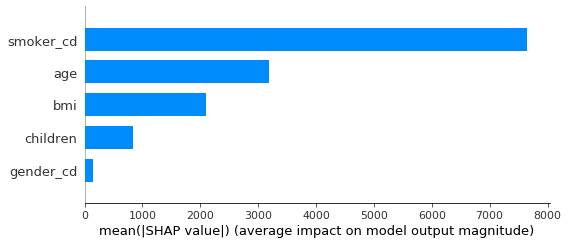

In [0]:
import shap
shap_values = shap.Explainer(rf).shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

In [0]:
# Get the predictions and put them with the test data.
X_output = X_test.copy()
X_output.loc[:,'predict'] = np.round(rf.predict(X_output),2)

# Sort by highest to lowest predicted probability 
X_output_sorted= X_output.sort_values('predict',ascending=False)

# pick Top 100 observations
S2 = X_output_sorted.head(100)
S2

,age,bmi,children,gender_cd,smoker_cd,predict
953,44,30.200,2,0,1,53535.82
742,53,34.105,0,0,1,50871.61
420,64,33.880,0,0,1,49545.49
252,54,34.210,2,0,1,49487.00
845,60,32.450,0,1,1,49000.21
...,...,...,...,...,...,...
722,62,37.400,0,0,0,13865.80
190,61,31.570,0,0,0,13865.80
550,63,30.800,0,0,0,13865.80
642,61,33.915,0,0,0,13865.80


In [0]:
X_test_new = S2.drop(['predict'], axis=1)
wfall_exapliner = shap.Explainer(rf, X_test_new)
shap_values_waterfall = wfall_exapliner(X_test_new)

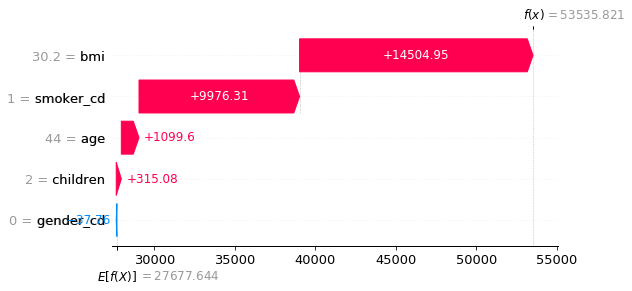

In [0]:
shap.plots.waterfall(shap_values_waterfall[0], max_display=20)

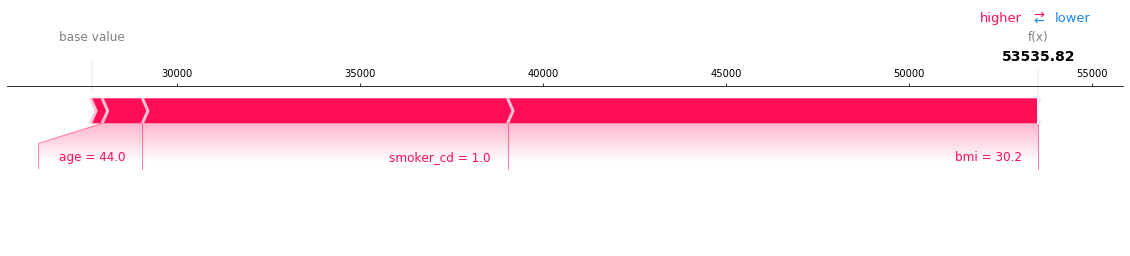

In [0]:
shap.plots.force(shap_values_waterfall[0], matplotlib=True)

In [0]:
column_names = X_test_new.columns.values.tolist()
column_names

Out[10]: ['age', 'bmi', 'children', 'gender_cd', 'smoker_cd']

In [0]:
shap_values_waterfall[0]

Out[11]: .values =
array([ 1099.59851273, 14504.94544468, 315.0835688 , -37.76071136,
 9976.31072266])

.base_values =
27677.64353018093

.data =
array([44. , 30.2, 2. , 0. , 1. ])

## Assignment 3.2

1. Use your unique number for seed (maybe use combination derived from your phone number) and 10 estimators to build the model
1. Use the place of first letter from your first name in english alphabet list (Remember there are 26 alphabets in English from A-Z) to identify a record and show that record's waterfall plot, force plot, and actual SHAP values e.g. H is the first letter in Harpreet and H is 8th alpahabet in english alphabet list so I will pick the 8th record for this solution, L is the first letter in Lance and L is the 12th alphabet in english alphabet list so Lance will pick the 12th highest scored record to show the plots 
NOTE: Make sure you write down your first name at the end of the notebook either in a Commented cell or a Markdown cell like this one